# Why campaign overlap changes: a behavioral synthetic market

The first notebook illustrates the calibration arithmetic using two pre-specified overlap populations. This notebook asks a harder question: can three campaign patterns emerge from plausible differences in people and delivery, without assigning an overlap rate to any campaign?

The simulated people differ in publisher and placement activity, response propensity, conversion propensity, auction cost, and stable-fingerprint availability. Every campaign uses the same broad declared audience. Campaigns differ only in objective, scale, flight length, placement mix, and the local opportunity and cost surfaces they encounter. Cross-publisher overlap is an **output** of those delivery conditions.

This is a public, synthetic mechanism study. Its parameters are deliberately rounded and illustrative. It reproduces qualitative shapes, not confidential measurements and not a claim about any real delivery system.

In [1]:
import os
import subprocess
import sys
from pathlib import Path

if "google.colab" in sys.modules:
    repo = Path("/content/calibrated-vid")
    if not repo.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                "stevenwarejones_behavioral_scenarios",
                "https://github.com/world-federation-of-advertisers/calibrated-vid.git",
                str(repo),
            ],
            check=True,
        )
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", "-e", str(repo)],
        check=True,
    )
    os.chdir(repo)

repo_root = Path.cwd()
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

## Three stress tests

1. **Traffic versus Reach.** The two campaigns have identical publisher reaches, duration, placement mix, auction state, and broad target. Only the optimization objective changes.
2. **Medium→large versus large→medium.** The same Reach campaign is run twice with publisher sizes reversed. This isolates publisher direction from objective and campaign settings.
3. **Variation within large Reach.** Every campaign has the same large reach on both publishers and the same broad target. Flight length, placement mix, and publisher-local opportunity and auction prices vary.

The fixed model learns one overlap rate from large Reach training campaigns. A second model uses the same baseline plus a coverage-corrected shared-fingerprint signal. No evaluation labels are used during fitting.

## Why Reach can vary without behavioral targeting

A Reach campaign does not need to predict clicks or explicitly target “publisher-loyal” people for its delivered cohort to vary.

1. The broad target only defines who is eligible. It does not make every eligible person equally available or equally expensive.
2. People generate different amounts of feed, story, and short-video inventory on each publisher.
3. A Reach buyer seeking new people encounters the cheapest eligible opportunities first. The cost ordering can differ by publisher, placement, flight, and auction state.
4. Each publisher selects its fixed number of reached people from its own opportunity and price ordering. It never observes activity on the other publisher.
5. Cross-publisher overlap is calculated only after the two local selections have been made.

The resulting audience can therefore differ even when two campaigns share a declared audience and neither campaign optimizes for response. This notebook models that distinction explicitly: **eligibility is held broad; each publisher's local opportunity and price ordering determine delivery.**

In [2]:
from pathlib import Path
import html
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display

from calibrated_vid.behavioral_market import (
    SEGMENTS,
    MarketConfig,
    behavioral_diagnostics,
    run_behavioral_experiment,
    simulate_market,
)

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
OUTPUT = ROOT / "outputs" / "behavioral_market"

campaigns, predictions, model, report = run_behavioral_experiment(OUTPUT)

def show_table(rows, columns, digits=2):
    head = "".join(f"<th>{html.escape(label)}</th>" for _, label in columns)
    body = []
    for row in rows:
        values = []
        for key, _ in columns:
            value = row[key]
            if isinstance(value, float):
                value = f"{value:.{digits}f}"
            values.append(f"<td>{html.escape(str(value))}</td>")
        body.append("<tr>" + "".join(values) + "</tr>")
    display(HTML("<table><thead><tr>" + head + "</tr></thead><tbody>" + "".join(body) + "</tbody></table>"))

report["model"]

{'fixed_overlap_rate': 0.29404991319444446,
 'reference_center': 0.3356370132482325,
 'reference_sensitivity': 0.9142201710367571}

## The latent audience

The market contains nine archetypes. They are not advertiser targeting labels and not mutually exclusive claims about real people. They compactly represent heterogeneous availability and delivery economics inside one broad eligible audience.

- **Dual-feed regulars** generate frequent feed opportunities on both publishers and are relatively inexpensive to reach.
- **Publisher-heavy regulars** generate much more inventory on one publisher than the other. Campaigns do not target them explicitly; they enter when that publisher and placement supply is economical.
- **Publisher-specific clickers** respond on one publisher much more often than the other. Traffic delivery can select different people on each side even under the same declared audience.
- **Short-video regulars** generate abundant short-video inventory on one publisher but less matching inventory elsewhere. Placement mix can therefore change the delivered cohort.
- **Dual clickers and converters** respond on both publishers but are more expensive to reach. They show why a non-Reach objective can also move overlap upward rather than downward.
- **Occasional dual users** enter only when a campaign has enough delivery opportunity.

Reach selection uses publisher-local opportunity ÷ auction cost. Traffic and Conversion multiply that value by publisher-local response propensity, with Conversion more selective than Traffic. No publisher uses the other publisher's activity, overlap, or fingerprint signal to deliver ads. The medium and large audiences are 5% and 20% of the synthetic market, respectively.

### How campaign-level delivery variation is modeled

The archetypes above describe persistent differences among people. On their own, however, they would make campaigns with the same objective and reach behave almost identically. The experiment also needs a simple representation of why real campaigns using the same broad eligible audience may encounter different portions of that audience.

A broad audience is not offered to a campaign as a uniform random sample. People create different amounts of publisher-local inventory, use different placements, appear at different times, and enter auctions at different prices. The simulator represents those conditions in three steps:

1. **Objective ranking.** Reach values economical opportunities without using response behavior. Traffic and Conversion also use relative response scores. These are ranking inputs, not literal probabilities: scores of 0.45 and 0.18 mean 2.5 times as much response weight, not 45% and 18% click rates.
2. **Publisher-local opportunity and cost.** For every campaign, each publisher independently varies how available and expensive each archetype is. The shifts are multiplicative because opportunity and price cannot be negative. A one-standard-deviation shift changes opportunity by about 2.0× or cost by about 1.8×. Neither publisher observes the other publisher's audience or the resulting overlap.
3. **Direction stress.** A medium campaign stops within the inexpensive portion of a publisher's supply curve, while a large campaign reaches farther into it. The directional test deliberately gives the two publishers different inexpensive cohorts. Its 1.4 log-cost contrast makes favored opportunity cost about 25% of its base level and selected alternatives about 2× their base level. Reversing which publisher supplies the medium audience can then change the intersection without changing either reach total.

These are intentionally broad stress settings. They make the proposed mechanisms easy to see and allow the notebook to test whether a fixed overlap assumption can fail. They are not estimates of actual response rates, inventory, or auction prices. Reproducing a pattern here establishes possibility, not its real-world cause or magnitude.

In [3]:
segment_rows = [
    {
        "segment": segment.name,
        "share %": 100 * segment.share,
        "feed activity A": segment.feed_activity_a,
        "feed activity B": segment.feed_activity_b,
        "short activity A": segment.short_video_activity_a,
        "short activity B": segment.short_video_activity_b,
        "click score A": segment.click_score_a,
        "click score B": segment.click_score_b,
        "conversion score": segment.conversion_score,
        "cost A": segment.cost_a,
        "cost B": segment.cost_b,
    }
    for segment in SEGMENTS
]
show_table(
    segment_rows,
    [
        ("segment", "Segment"),
        ("share %", "Population %"),
        ("feed activity A", "Feed activity A"),
        ("feed activity B", "Feed activity B"),
        ("short activity A", "Short-video A"),
        ("short activity B", "Short-video B"),
        ("click score A", "Relative click score A"),
        ("click score B", "Relative click score B"),
        ("conversion score", "Relative conversion score"),
        ("cost A", "Cost A"),
        ("cost B", "Cost B"),
    ],
)

Segment,Population %,Feed activity A,Feed activity B,Short-video A,Short-video B,Relative click score A,Relative click score B,Relative conversion score,Cost A,Cost B
dual_feed_regulars,22.00,0.92,0.88,0.42,0.48,0.02,0.02,0.00,0.35,0.35
publisher_a_regulars,15.00,0.95,0.24,0.72,0.11,0.02,0.01,0.00,0.85,1.24
publisher_b_regulars,18.00,0.20,0.96,0.10,0.79,0.01,0.02,0.00,1.34,0.85
publisher_a_clickers,12.00,0.86,0.32,0.66,0.20,0.45,0.00,0.02,1.28,1.02
publisher_b_clickers,12.00,0.31,0.87,0.18,0.72,0.00,0.45,0.02,1.02,1.31
short_video_a_regulars,8.00,0.25,0.16,0.96,0.23,0.08,0.01,0.01,0.70,1.10
short_video_b_regulars,8.00,0.17,0.24,0.20,0.97,0.01,0.08,0.01,1.12,0.58
high_intent_dual,3.00,0.67,0.66,0.48,0.51,0.18,0.18,0.06,2.10,2.10
occasional_dual,2.00,0.32,0.31,0.20,0.19,0.03,0.03,0.01,0.84,0.84


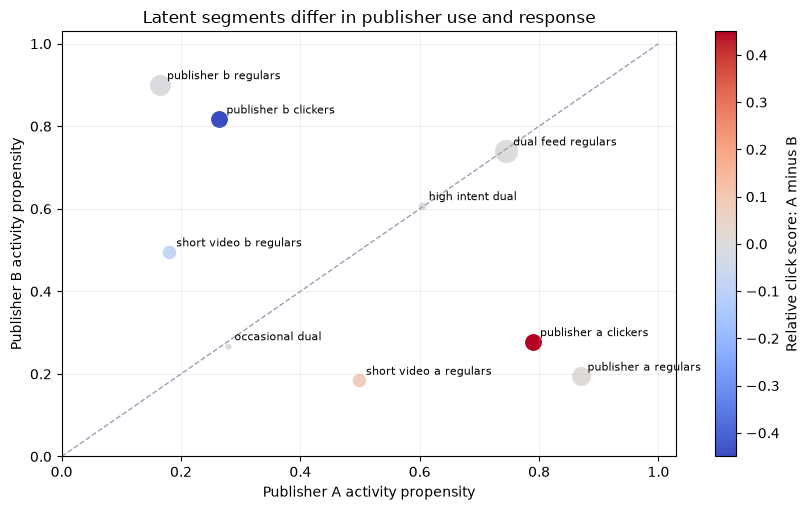

In [4]:
fig, ax = plt.subplots(figsize=(8.5, 5.2))
normalizer = plt.Normalize(-0.45, 0.45)
mapper = plt.cm.ScalarMappable(norm=normalizer, cmap="coolwarm")
for segment in SEGMENTS:
    click_asymmetry = segment.click_score_a - segment.click_score_b
    activity_a = 0.65 * segment.feed_activity_a + 0.35 * segment.short_video_activity_a
    activity_b = 0.65 * segment.feed_activity_b + 0.35 * segment.short_video_activity_b
    ax.scatter(
        activity_a,
        activity_b,
        s=1400 * segment.share,
        color=mapper.to_rgba(click_asymmetry),
        edgecolor="white",
        linewidth=0.8,
    )
    ax.annotate(segment.name.replace("_", " "), (activity_a, activity_b), xytext=(5, 4), textcoords="offset points", fontsize=8)
ax.plot([0, 1], [0, 1], color="#94a3b8", linewidth=1, linestyle="--")
ax.set(
    xlabel="Publisher A activity propensity",
    ylabel="Publisher B activity propensity",
    title="Latent segments differ in publisher use and response",
    xlim=(0, 1.03),
    ylim=(0, 1.03),
)
ax.grid(alpha=0.18)
fig.colorbar(mapper, ax=ax, label="Relative click score: A minus B")
fig.tight_layout()
fig.savefig(OUTPUT / "latent_segments.png", dpi=180)
plt.show()

## Test 1: Traffic versus Reach

Each point is one matched synthetic campaign condition. Reach and Traffic use the same broad audience, placement mix, local opportunity and cost state, duration, and publisher reach. Only the delivery objective changes.

Reach buys inexpensive eligible impressions without using click propensity. Traffic ranks publisher-specific responders more highly. Because many strong responders differ by publisher, the two Traffic audiences intersect less often.

The diagonal means equal overlap. Points below it are Traffic campaigns with lower overlap than their matched Reach campaign.

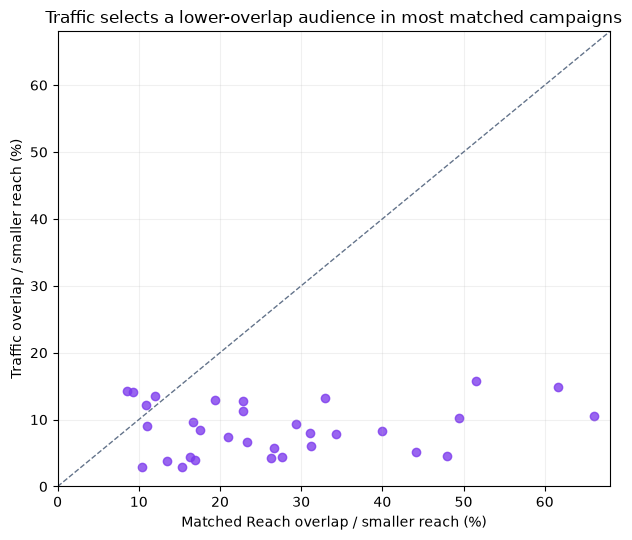

Matched pairs,Traffic lower share %,Median Traffic − Reach (points),P10 difference,P90 difference
32,87.50,-15.06,-39.16,1.02


In [5]:
evaluation = [campaign for campaign in campaigns if campaign.split == "evaluation"]
by_pair = {}
for campaign in evaluation:
    by_pair.setdefault(campaign.comparison_id, {})[campaign.scenario] = campaign
objective_pairs = [
    (rows["reach_large_large"], rows["traffic_large_large"])
    for rows in by_pair.values()
    if "reach_large_large" in rows and "traffic_large_large" in rows
]

fig, ax = plt.subplots(figsize=(6.3, 5.5))
reach_rates = 100 * np.asarray([reach.overlap_rate for reach, _ in objective_pairs])
traffic_rates = 100 * np.asarray([traffic.overlap_rate for _, traffic in objective_pairs])
ax.scatter(reach_rates, traffic_rates, color="#7c3aed", alpha=0.78)
limit = max(reach_rates.max(), traffic_rates.max()) + 2
ax.plot([0, limit], [0, limit], color="#64748b", linestyle="--", linewidth=1)
ax.set(
    xlabel="Matched Reach overlap / smaller reach (%)",
    ylabel="Traffic overlap / smaller reach (%)",
    title="Traffic selects a lower-overlap audience in most matched campaigns",
    xlim=(0, limit),
    ylim=(0, limit),
)
ax.grid(alpha=0.18)
fig.tight_layout()
fig.savefig(OUTPUT / "objective_pairing.png", dpi=180)
plt.show()

objective_diagnostic = dict(report["diagnostics"]["paired_objective_test"])
objective_diagnostic["traffic_lower_percent"] = 100 * objective_diagnostic["traffic_lower_share"]
show_table(
    [objective_diagnostic],
    [
        ("pairs", "Matched pairs"),
        ("traffic_lower_percent", "Traffic lower share %"),
        ("traffic_minus_reach_median_points", "Median Traffic − Reach (points)"),
        ("traffic_minus_reach_p10_points", "P10 difference"),
        ("traffic_minus_reach_p90_points", "P90 difference"),
    ],
)

> **Test 1 TL;DR.** A single mean or median learned from large Reach campaigns cannot represent the matched Traffic campaigns in this synthetic market. Traffic produces lower overlap in most pairs, with a 15-point median within-pair gap. Applying the larger Reach overlap therefore overstates the shared audience and understates the additional unique audience contributed by the second publisher.

## Test 2: medium→large versus large→medium

The paired campaigns below use the same Reach objective, duration, placement mix, local opportunity and cost state, and broad target. The only change is which publisher supplies the large audience.

Each publisher has a different cost-ranked opportunity curve because people generate different inventory across publishers and placements. A medium audience samples the cheapest part of that curve; a large audience reaches farther into it. Reversing which publisher supplies the medium audience can therefore change the intersection even though the two numeric reach inputs are unchanged.

This stress test deliberately makes that asymmetry strong: publisher A's inexpensive opportunity is feed-heavy and concentrated among regular users, while publisher B's inexpensive opportunity is short-video-heavy and concentrated in a smaller publisher-specific band. Neither campaign targets those people explicitly. The difference emerges from publisher-local placement availability and auction price.

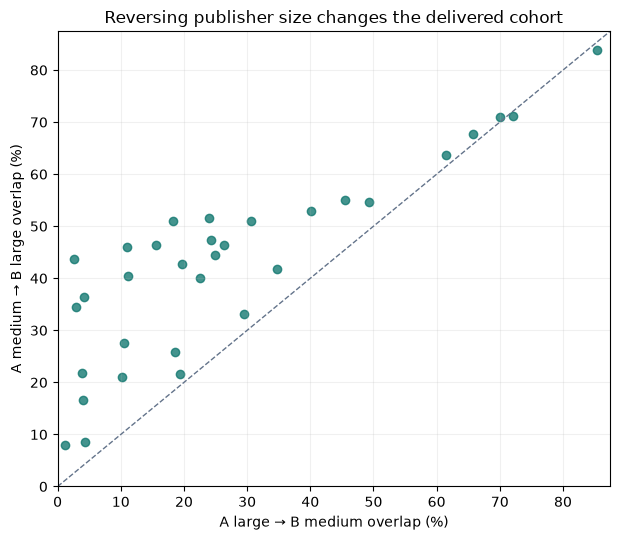

Matched pairs,Medium→large higher share %,Median direction gap (points),P10 gap,P90 gap
32,93.75,14.94,1.95,32.23


In [6]:
direction_pairs = [
    (rows["reach_medium_large"], rows["reach_large_medium"])
    for rows in by_pair.values()
    if "reach_medium_large" in rows and "reach_large_medium" in rows
]

fig, ax = plt.subplots(figsize=(6.3, 5.5))
medium_large = 100 * np.asarray([left.overlap_rate for left, _ in direction_pairs])
large_medium = 100 * np.asarray([right.overlap_rate for _, right in direction_pairs])
ax.scatter(large_medium, medium_large, color="#0f766e", alpha=0.78)
limit = max(medium_large.max(), large_medium.max()) + 2
ax.plot([0, limit], [0, limit], color="#64748b", linestyle="--", linewidth=1)
ax.set(
    xlabel="A large → B medium overlap (%)",
    ylabel="A medium → B large overlap (%)",
    title="Reversing publisher size changes the delivered cohort",
    xlim=(0, limit),
    ylim=(0, limit),
)
ax.grid(alpha=0.18)
fig.tight_layout()
fig.savefig(OUTPUT / "direction_pairing.png", dpi=180)
plt.show()

direction_diagnostic = dict(report["diagnostics"]["paired_direction_test"])
direction_diagnostic["medium_large_higher_percent"] = 100 * direction_diagnostic["medium_large_higher_share"]
show_table(
    [direction_diagnostic],
    [
        ("pairs", "Matched pairs"),
        ("medium_large_higher_percent", "Medium→large higher share %"),
        ("medium_large_minus_large_medium_median_points", "Median direction gap (points)"),
        ("medium_large_minus_large_medium_p10_points", "P10 gap"),
        ("medium_large_minus_large_medium_p90_points", "P90 gap"),
    ],
)

> **Test 2 TL;DR.** A single large-to-large Reach average cannot represent both asymmetric size directions. The medium-to-large configuration has a 15-point higher median within-pair overlap than the reversed configuration, despite using the same objective, sizes, target, and delivery conditions. The fixed baseline consequently understates overlap in one direction and overstates it in the other, reversing the direction of the unique-reach error.

## Test 3: variance within large Reach

All campaigns in this chart have exactly the same large reach on both publishers. They still occupy different overlap regimes.

Each publisher independently encounters a different local opportunity and price surface. Flight length and placement mix change which portion of the same broad audience is available and economical. The chart orders campaigns by the resulting overlap to make the P10 to P90 range visible; it does not use overlap as a delivery input. No campaign explicitly targets a latent audience type.

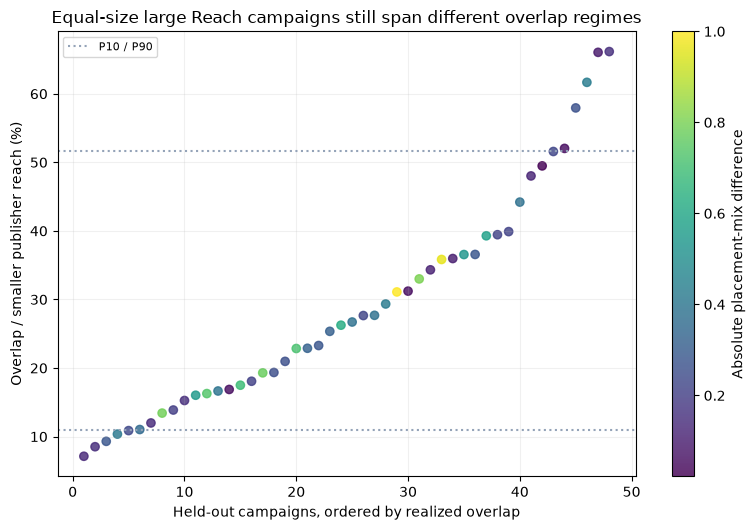

Campaigns,P10 overlap %,Median overlap %,P90 overlap %,P10–P90 width (points)
48,10.98,26.48,51.71,40.73


In [7]:
large_reach = sorted(
    [campaign for campaign in evaluation if campaign.scenario == "reach_large_large"],
    key=lambda campaign: campaign.overlap_rate,
)
fig, ax = plt.subplots(figsize=(8.0, 5.4))
placement_asymmetry = np.asarray([
    abs(campaign.short_video_share_a - campaign.short_video_share_b)
    for campaign in large_reach
])
points = ax.scatter(
    np.arange(1, len(large_reach) + 1),
    [100 * campaign.overlap_rate for campaign in large_reach],
    c=placement_asymmetry,
    cmap="viridis",
    alpha=0.82,
)
diagnostic = report["diagnostics"]["within_large_reach"]
ax.axhline(diagnostic["overlap_p10_percent"], color="#94a3b8", linestyle=":", label="P10 / P90")
ax.axhline(diagnostic["overlap_p90_percent"], color="#94a3b8", linestyle=":")
ax.set(
    xlabel="Held-out campaigns, ordered by realized overlap",
    ylabel="Overlap / smaller publisher reach (%)",
    title="Equal-size large Reach campaigns still span different overlap regimes",
)
ax.grid(alpha=0.18)
ax.legend(fontsize=8)
fig.colorbar(points, ax=ax, label="Absolute placement-mix difference")
fig.tight_layout()
fig.savefig(OUTPUT / "large_reach_variance.png", dpi=180)
plt.show()

show_table(
    [diagnostic],
    [
        ("campaigns", "Campaigns"),
        ("overlap_p10_percent", "P10 overlap %"),
        ("overlap_median_percent", "Median overlap %"),
        ("overlap_p90_percent", "P90 overlap %"),
        ("overlap_p10_p90_width_points", "P10–P90 width (points)"),
    ],
)

### Robustness across deterministic market draws

The figures above show one reproducible synthetic market. To avoid treating that seed as evidence, the table below repeats the complete experiment across six pre-specified seeds and summarizes the results. The qualitative failure modes should persist; their exact magnitudes are not claims about real campaigns.

In [8]:
robustness_seeds = [20260927, 20260928, 20260929, 20260930, 20261001, 20261002]
seed_diagnostics = []
for seed in robustness_seeds:
    seed_diagnostics.append(
        behavioral_diagnostics(simulate_market(MarketConfig(random_seed=seed)))
    )

robustness_metrics = {
    "Traffic lower share (%)": [
        100 * row["paired_objective_test"]["traffic_lower_share"]
        for row in seed_diagnostics
    ],
    "Reach minus Traffic median gap (points)": [
        -row["paired_objective_test"]["traffic_minus_reach_median_points"]
        for row in seed_diagnostics
    ],
    "Direction median gap (points)": [
        row["paired_direction_test"]["medium_large_minus_large_medium_median_points"]
        for row in seed_diagnostics
    ],
    "Large Reach P10 overlap (%)": [
        row["within_large_reach"]["overlap_p10_percent"]
        for row in seed_diagnostics
    ],
    "Large Reach P90 overlap (%)": [
        row["within_large_reach"]["overlap_p90_percent"]
        for row in seed_diagnostics
    ],
}
robustness_rows = [
    {
        "metric": metric,
        "median": float(np.median(values)),
        "minimum": float(np.min(values)),
        "maximum": float(np.max(values)),
    }
    for metric, values in robustness_metrics.items()
]
show_table(
    robustness_rows,
    [
        ("metric", "Metric across six synthetic markets"),
        ("median", "Median"),
        ("minimum", "Minimum"),
        ("maximum", "Maximum"),
    ],
)

Metric across six synthetic markets,Median,Minimum,Maximum
Traffic lower share (%),96.88,87.50,100.00
Reach minus Traffic median gap (points),22.17,15.06,29.27
Direction median gap (points),13.25,10.52,20.23
Large Reach P10 overlap (%),14.59,10.98,16.73
Large Reach P90 overlap (%),55.87,51.31,66.35


> **Test 3 TL;DR.** Even within equal-size large Reach campaigns, one central overlap value represents only the middle of a wide distribution. Applying the training mean or median to every campaign necessarily overstates overlap for low-overlap campaigns and understates it for high-overlap campaigns, producing material errors in both directions. The across-seed check shows that the dispersion is not unique to one random market draw.

## Does a campaign reference help?

The fixed model applies the average large Reach overlap to every campaign. The reference model observes only a subset:

- 30% fingerprint coverage on publisher A;
- 80% fingerprint coverage on publisher B;
- 60% agreement when the same person has fingerprints on both.

Coverage also varies by latent segment, so dividing by the aggregate observation probability is not perfect. The model learns one sensitivity from large Reach training campaigns and applies it unchanged to Traffic, Conversion, and both publisher-size directions.

This is an **upper-bound feasibility demonstration**, not independent validation. The reference matches are generated by thinning the simulator's true shared-person set using the stated coverage and agreement process, so the reference is structurally informative. A real deployment would require independent person-level calibration labels and tests of whether fingerprint-bearing people represent the rest of each campaign.

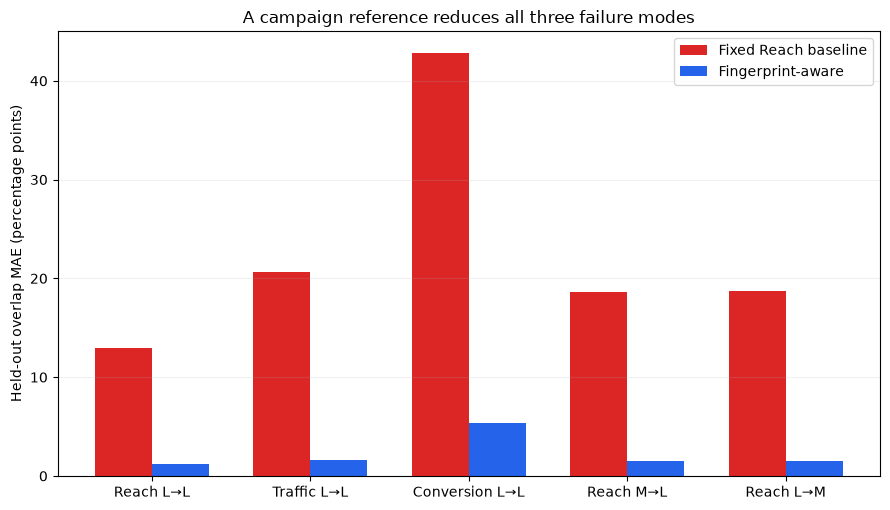

Scenario,Overlap P10 %,Overlap median %,Overlap P90 %,Fixed MAE points,Reference MAE points,Fixed union MAPE %,Reference union MAPE %
reach_large_large,10.98,26.48,51.71,12.93,1.24,7.88,0.74
traffic_large_large,3.97,8.37,14.07,20.69,1.60,10.78,0.84
conversion_large_large,61.98,73.56,81.16,42.87,5.37,33.92,4.26
reach_medium_large,21.17,44.04,67.27,18.62,1.51,4.16,0.34
reach_large_medium,3.84,21.12,65.30,18.73,1.56,4.04,0.34


In [9]:
scenario_rows = report["scenarios"]
labels = {
    "reach_large_large": "Reach L→L",
    "traffic_large_large": "Traffic L→L",
    "conversion_large_large": "Conversion L→L",
    "reach_medium_large": "Reach M→L",
    "reach_large_medium": "Reach L→M",
}
ordered = [
    next(row for row in scenario_rows if row["scenario"] == scenario)
    for scenario in labels
]
x = np.arange(len(ordered))
width = 0.36
fig, ax = plt.subplots(figsize=(9.0, 5.2))
ax.bar(x - width / 2, [row["fixed_overlap_mae_points"] for row in ordered], width, label="Fixed Reach baseline", color="#dc2626")
ax.bar(x + width / 2, [row["calibrated_overlap_mae_points"] for row in ordered], width, label="Fingerprint-aware", color="#2563eb")
ax.set(
    ylabel="Held-out overlap MAE (percentage points)",
    title="A campaign reference reduces all three failure modes",
    xticks=x,
    xticklabels=[labels[row["scenario"]] for row in ordered],
)
ax.grid(axis="y", alpha=0.18)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT / "model_error.png", dpi=180)
plt.show()

show_table(
    ordered,
    [
        ("scenario", "Scenario"),
        ("overlap_p10_percent", "Overlap P10 %"),
        ("overlap_median_percent", "Overlap median %"),
        ("overlap_p90_percent", "Overlap P90 %"),
        ("fixed_overlap_mae_points", "Fixed MAE points"),
        ("calibrated_overlap_mae_points", "Reference MAE points"),
        ("fixed_union_mape_percent", "Fixed union MAPE %"),
        ("calibrated_union_mape_percent", "Reference union MAPE %"),
    ],
)

## Final result: how calibrated VID improves all three stress tests

Let $R_A$ and $R_B$ be the two publisher reaches, $S=\min(R_A,R_B)$, and $q=O/S$ be overlap as a share of smaller reach. Then:

$$O=qS$$

$$U=R_A+R_B-O$$

$$I=S-O=S(1-q)$$

where $U$ is total cross-publisher unique reach and $I$ is the unique audience contributed by the smaller publisher. If a model predicts $\hat q$, its relative incremental-unique error is:

$$\frac{\hat I-I}{I}=\frac{q-\hat q}{1-q}$$

This is why a seemingly moderate overlap error can badly misstate the smaller publisher's contribution. The left chart compares actual and predicted overlap levels. The right chart applies the equation above and reports the held-out P90 absolute error in incremental unique reach.

The four displayed cohorts cover the three requested tests: Traffic versus Reach, both orientations of the publisher-size reversal, and residual variation among equal-size large Reach campaigns.

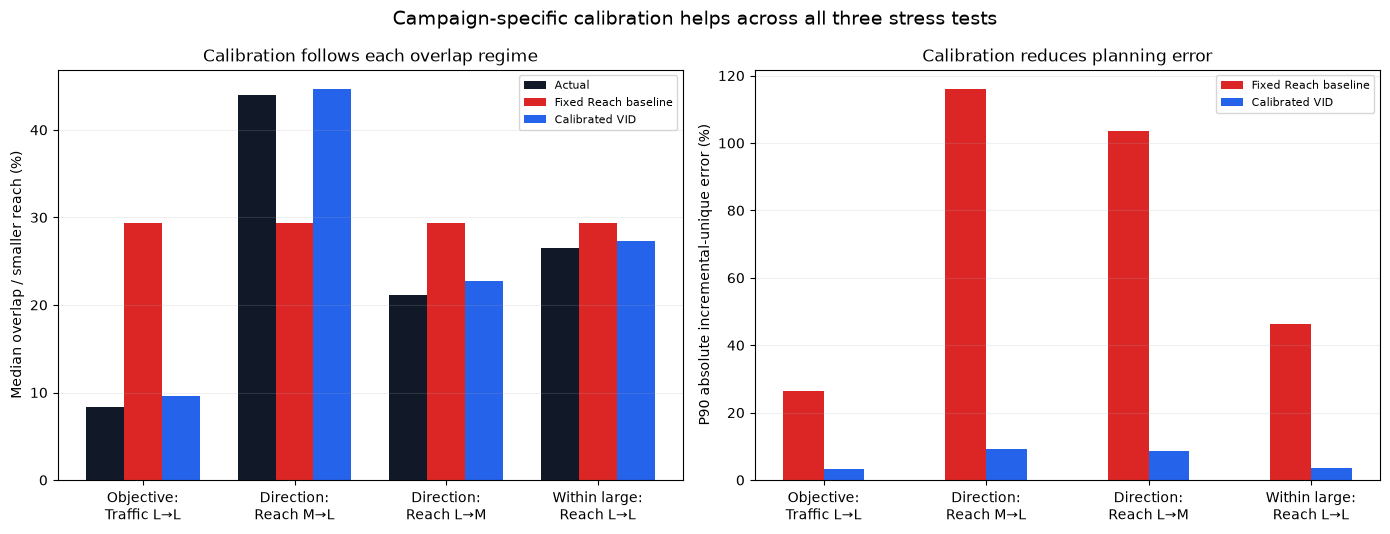

Synthetic cohort,Actual median overlap %,Fixed prediction %,Calibrated median %,Fixed incremental P90 error %,Calibrated incremental P90 error %,Fixed union MAPE %,Calibrated union MAPE %
traffic_large_large,8.37,29.40,9.62,26.49,3.30,10.78,0.84
reach_medium_large,44.04,29.40,44.63,115.93,9.10,4.16,0.34
reach_large_medium,21.12,29.40,22.79,103.71,8.55,4.04,0.34
reach_large_large,26.48,29.40,27.29,46.21,3.71,7.88,0.74


In [10]:
final_scenarios = [
    "traffic_large_large",
    "reach_medium_large",
    "reach_large_medium",
    "reach_large_large",
]
final_labels = {
    "traffic_large_large": "Objective:\nTraffic L→L",
    "reach_medium_large": "Direction:\nReach M→L",
    "reach_large_medium": "Direction:\nReach L→M",
    "reach_large_large": "Within large:\nReach L→L",
}
final_rows = [
    next(row for row in scenario_rows if row["scenario"] == scenario)
    for scenario in final_scenarios
]
x = np.arange(len(final_rows))
width = 0.25
fig, axes = plt.subplots(1, 2, figsize=(14.0, 5.4))

axes[0].bar(
    x - width,
    [row["overlap_median_percent"] for row in final_rows],
    width,
    label="Actual",
    color="#111827",
)
axes[0].bar(
    x,
    [row["fixed_overlap_percent"] for row in final_rows],
    width,
    label="Fixed Reach baseline",
    color="#dc2626",
)
axes[0].bar(
    x + width,
    [row["calibrated_overlap_median_percent"] for row in final_rows],
    width,
    label="Calibrated VID",
    color="#2563eb",
)
axes[0].set(
    ylabel="Median overlap / smaller reach (%)",
    title="Calibration follows each overlap regime",
    xticks=x,
    xticklabels=[final_labels[row["scenario"]] for row in final_rows],
)
axes[0].grid(axis="y", alpha=0.18)
axes[0].legend(fontsize=8)

axes[1].bar(
    x - width / 2,
    [row["fixed_incremental_p90_error_percent"] for row in final_rows],
    width,
    label="Fixed Reach baseline",
    color="#dc2626",
)
axes[1].bar(
    x + width / 2,
    [row["calibrated_incremental_p90_error_percent"] for row in final_rows],
    width,
    label="Calibrated VID",
    color="#2563eb",
)
axes[1].set(
    ylabel="P90 absolute incremental-unique error (%)",
    title="Calibration reduces planning error",
    xticks=x,
    xticklabels=[final_labels[row["scenario"]] for row in final_rows],
)
axes[1].grid(axis="y", alpha=0.18)
axes[1].legend(fontsize=8)

fig.suptitle("Campaign-specific calibration helps across all three stress tests", fontsize=14)
fig.tight_layout()
fig.savefig(OUTPUT / "final_calibration_impact.png", dpi=180)
plt.show()

show_table(
    final_rows,
    [
        ("scenario", "Synthetic cohort"),
        ("overlap_median_percent", "Actual median overlap %"),
        ("fixed_overlap_percent", "Fixed prediction %"),
        ("calibrated_overlap_median_percent", "Calibrated median %"),
        ("fixed_incremental_p90_error_percent", "Fixed incremental P90 error %"),
        ("calibrated_incremental_p90_error_percent", "Calibrated incremental P90 error %"),
        ("fixed_union_mape_percent", "Fixed union MAPE %"),
        ("calibrated_union_mape_percent", "Calibrated union MAPE %"),
    ],
)

## What the experiment establishes

The same marginal publisher reaches do not determine the intersection.

1. **Objective changes the effective cohort.** Publisher-specific response propensity makes matched Traffic delivery systematically lower-overlap than Reach delivery.
2. **Publisher direction can matter.** Reversing medium and large sizes changes which publisher-specific cohort is exhausted, even though the two numeric reach inputs are unchanged.
3. **Large is not homogeneous.** Equal-size large Reach campaigns retain a wide distribution because publisher-local opportunity, placement mix, flight length, and auction cost surfaces differ, even under one broad declared audience.
4. **A campaign-specific reference can expose the missing relationship.** It improves every held-out scenario while preserving both single-publisher reaches.

The experiment does not identify the cause of any real campaign, validate a production model, or prove that fingerprint-bearing people represent everyone else. No parameter or result is estimated from production data. Its purpose is narrower: to demonstrate a coherent population-and-delivery mechanism capable of producing three hypothetical failure shapes.